In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization
from keras.optimizers import SGD
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import ModelCheckpoint,EarlyStopping
from tensorflow.keras.layers import Conv2D,Flatten,MaxPooling2D,Dense,Dropout,MaxPool2D
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/digit_train.csv')

df

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41996,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41997,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41998,6,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:

Y_train = df[["label"]]
X_train = df.drop(labels=["label"],axis=1)

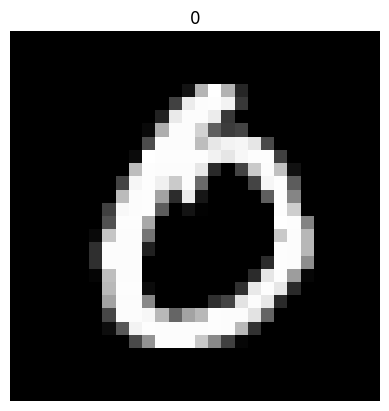

In [ ]:
def img_visualize(X_train,num):
    img = X_train.iloc[num].to_numpy()
    img = img.reshape((28,28))
    plt.imshow(img,cmap="gray")
    plt.title(df.iloc[num]['label'])
    plt.axis("off")
    plt.show()
img_visualize(X_train,num=200)

In [ ]:
encoder = OneHotEncoder(sparse_output=False)

encoded_labels = encoder.fit_transform(df[['label']])#used double [[]] to convert series into array

#creating a column
encoded_df = pd.DataFrame(encoded_labels, columns=encoder.get_feature_names_out(['label']))

# Concatenate the encoded labels with the original DataFrame

df = pd.concat([df, encoded_df], axis=1)

In [ ]:
df

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,label_0,label_1,label_2,label_3,label_4,label_5,label_6,label_7,label_8,label_9
0,1,0,0,0,0,0,0,0,0,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0,0,0,0,0,0,0,0,0,0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1,0,0,0,0,0,0,0,0,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,0,0,0,0,0,0,0,0,0,0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41995,0,0,0,0,0,0,0,0,0,0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
41996,1,0,0,0,0,0,0,0,0,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
41997,7,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
41998,6,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [ ]:
df.drop('label',axis=1,inplace=True)
df

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,label_0,label_1,label_2,label_3,label_4,label_5,label_6,label_7,label_8,label_9
0,0,0,0,0,0,0,0,0,0,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0,0,0,0,0,0,0,0,0,0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0,0,0,0,0,0,0,0,0,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,0,0,0,0,0,0,0,0,0,0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41995,0,0,0,0,0,0,0,0,0,0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
41996,0,0,0,0,0,0,0,0,0,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
41997,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
41998,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [ ]:
df.describe()

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,label_0,label_1,label_2,label_3,label_4,label_5,label_6,label_7,label_8,label_9
count,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,...,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000
mean,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.098381,0.111524,0.099452,0.103595,0.096952,0.090357,0.098500,0.104786,0.096738,0.099714
std,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.297833,0.314783,0.299272,0.304738,0.295896,0.286696,0.297993,0.306281,0.295604,0.299622
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

# Build the model
model1 = Sequential()
model1.add(Flatten(input_shape=(28, 28, 1)))
# model1.add(Dense(512, activation='relu'))
# model1.add(BatchNormalization())
# model1.add(Dropout(0.2))

model1.add(Dense(256, activation='relu'))
model1.add(BatchNormalization())
model1.add(Dropout(0.3))

model1.add(Dense(128, activation='relu'))
model1.add(BatchNormalization())
model1.add(Dropout(0.3))
model1.add(Flatten())
model1.add(Dense(64, activation='relu'))
model1.add(BatchNormalization())
model1.add(Dropout(0.2))

model1.add(Dense(10, activation='softmax'))

# Compile the model1
model1.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

# Print summary
print(model1.summary())


/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 244,554 (955.29 KB)

 Trainable params: 243,658 (951.79 KB)

 Non-trainable params: 896 (3.50 KB)

None


In [ ]:
#Add Callbacks, e.g. ModelCheckpoints, earlystopping, csvlogger.
from keras.callbacks import ModelCheckpoint, EarlyStopping, CSVLogger

#ModelCheckpoint callback saves a model at some interval.

#Give unique name to save all models as accuracy improves
#filepath="/content/drive/MyDrive/Colab Notebooks/saved_models/weights-improvement-{epoch:02d}-{val_accuracy:.2f}.hdf5" #File name includes epoch and validation accuracy.

#Overwrite the model each time accuracy improves. Saves a lot of space.
#filepath="/content/drive/MyDrive/Colab Notebooks/saved_models/best_model.hdf5" #File name includes epoch and validation accuracy.
#Use Mode = max for accuracy and min for loss.
#checkpoint = ModelCheckpoint(filepath, monitor='val_accuracy', verbose=1, save_best_only=True, mode='max')

#https://www.tensorflow.org/api_docs/python/tf/keras/callbacks/EarlyStopping
early_stop = EarlyStopping(monitor='val_loss', patience=10, verbose=1)
#This callback will stop the training when there is no improvement in
# the validation loss for three consecutive epochs.

#CSVLogger logs epoch, accuracy, loss, val_accuracy, val_loss. So we can plot later.
#log_csv = CSVLogger('/content/drive/MyDrive/Colab Notebooks/saved_logs/my_logs.csv', separator=',', append=False)

callbacks_list = [early_stop]

In [ ]:
X = df.iloc[:,0:784]
X = X/255
print(X)

       pixel0  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  \
0         0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
1         0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
2         0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
3         0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
4         0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
...       ...     ...     ...     ...     ...     ...     ...     ...     ...   
41995     0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
41996     0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
41997     0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
41998     0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
41999     0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   

       pixel9  ...  pixel77

In [ ]:
y = df.iloc[:,784:]
print(y)

       label_0  label_1  label_2  label_3  label_4  label_5  label_6  label_7  \
0          0.0      1.0      0.0      0.0      0.0      0.0      0.0      0.0   
1          1.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0   
2          0.0      1.0      0.0      0.0      0.0      0.0      0.0      0.0   
3          0.0      0.0      0.0      0.0      1.0      0.0      0.0      0.0   
4          1.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0   
...        ...      ...      ...      ...      ...      ...      ...      ...   
41995      1.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0   
41996      0.0      1.0      0.0      0.0      0.0      0.0      0.0      0.0   
41997      0.0      0.0      0.0      0.0      0.0      0.0      0.0      1.0   
41998      0.0      0.0      0.0      0.0      0.0      0.0      1.0      0.0   
41999      0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0   

       label_8  label_9  
0

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)
X_train = X_train.values.reshape(-1, 28, 28, 1)  # Reshape to (num_samples, 28, 28, 1)
X_val = X_val.values.reshape(-1, 28, 28, 1)

In [ ]:
history = model1.fit(X_train,y_train,
                    epochs=25,
                    validation_data=(X_val,y_val),
                    callbacks=callbacks_list,
                   )

Epoch 1/25
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.7661 - loss: 0.7586 - val_accuracy: 0.9486 - val_loss: 0.1712
Epoch 2/25
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9168 - loss: 0.2733 - val_accuracy: 0.9565 - val_loss: 0.1385
Epoch 3/25
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9365 - loss: 0.2089 - val_accuracy: 0.9590 - val_loss: 0.1318
Epoch 4/25
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9444 - loss: 0.1857 - val_accuracy: 0.9679 - val_loss: 0.1103
Epoch 5/25
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9483 - loss: 0.1724 - val_accuracy: 0.9671 - val_loss: 0.1095
Epoch 6/25
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9547 - loss: 0.1543 - val_accuracy: 0.9664 - val_loss: 0.1062
Epoch 7/25
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9548 - loss: 0.1413 - val_accuracy: 0.9681 - val_loss: 0.1037
Epoch 8/25
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9621 - loss: 0.1249 -

In [ ]:
y_pred = model1.predict(X_val)
y_pred = np.argmax(y_pred, axis=1)  # Get predicted classes as indices

# Ensure y_test is derived correctly from y_val
y_test = np.argmax(y_val.values, axis=1)  # Convert DataFrame values to array and get true class indices

# Now you can calculate the confusion matrix
conf = confusion_matrix(y_test, y_pred)
print(conf)

263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
[[808   0   1   2   0   2   2   0   1   0]
 [  0 901   2   0   1   0   1   1   3   0]
 [  0   5 822   7   4   0   0   1   6   1]
 [  1   0   1 921   0   3   0   1   9   1]
 [  2   0   1   0 818   1   4   2   0  11]
 [  0   2   0  12   0 684   1   1   1   1]
 [  5   0   0   0   1   2 775   0   2   0]
 [  0   4   4   4   2   1   0 872   2   4]
 [  0   3   3   5   4   4   1   0 814   1]
 [  0   2   1  10   3   4   0   8   3 807]]


In [ ]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)
X_train = X_train.values.reshape(-1, 28, 28, 1)  # Reshape to (num_samples, 28, 28, 1)
X_val = X_val.values.reshape(-1, 28, 28, 1)

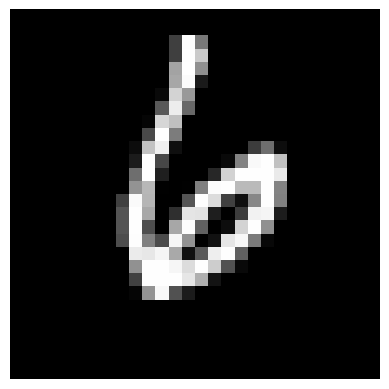

In [ ]:
plt.imshow(X_train[0][:,:,0],cmap="gray")
plt.axis("off")
plt.show()

In [ ]:
model = Sequential()
model.add(Conv2D(filters=32,kernel_size=(5,5),padding='Same',
                activation="relu",input_shape = (28,28,1)))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Dropout(0.25))
model.add(Conv2D(filters=64,kernel_size=(3,3),padding='Same',
                activation="relu"))
model.add(MaxPool2D(pool_size=(2,2),strides=(2,2)))
model.add(Dropout(0.25))
model.add(Flatten())
model.add(Dense(256,activation="relu"))
model.add(Dropout(0.5))
model.add(Dense(10,activation="softmax"))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │       803,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 824,970 (3.15 MB)

 Trainable params: 824,970 (3.15 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.optimizers import Adam
optimizer = Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999)
model.compile(loss="categorical_crossentropy",
             optimizer=optimizer,
             metrics=['accuracy'])
callbacks = [EarlyStopping(monitor='val_loss',patience=4,verbose=1,mode='min'),
            ModelCheckpoint(filepath='mymodel.keras',monitor='val_loss',mode='min',save_best_only=True,save_weights_only=False,verbose=1)]

In [ ]:
history = model.fit(X_train,y_train,
                    epochs=25,
                    validation_data=(X_val,y_val),
                    callbacks=callbacks,
                   )

Epoch 1/25
1035/1050 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8312 - loss: 0.5186
Epoch 1: val_loss improved from inf to 0.06022, saving model to mymodel.keras
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.8326 - loss: 0.5145 - val_accuracy: 0.9796 - val_loss: 0.0602
Epoch 2/25
1045/1050 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9711 - loss: 0.0944
Epoch 2: val_loss improved from 0.06022 to 0.03874, saving model to mymodel.keras
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9711 - loss: 0.0943 - val_accuracy: 0.9875 - val_loss: 0.0387
Epoch 3/25
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9796 - loss: 0.0684
Epoch 3: val_loss did not improve from 0.03874
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9796 - loss: 0.0684 - val_accuracy: 0.9868 - val_loss: 0.0403
Epoch 4/25
1042/1050 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9822 - loss: 0.0573
Epoch 4: val_loss improved from 0.03874 to 0.03792, saving model to mymodel.keras
1

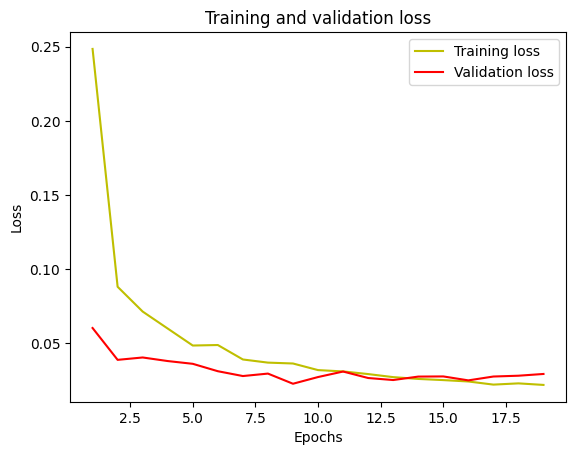

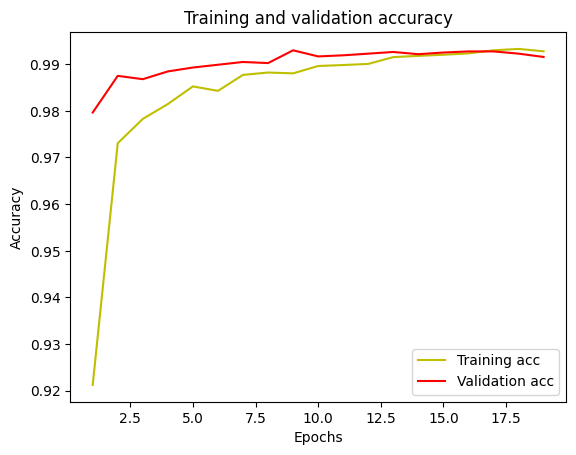

In [ ]:

loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'y', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
plt.plot(epochs, acc, 'y', label='Training acc')
plt.plot(epochs, val_acc, 'r', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [ ]:
results = model.evaluate(X_val, y_val, batch_size=32)

263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9911 - loss: 0.0309


In [ ]:
y_pred = model.predict(X_val)
print(y_pred[:5])

263/263 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
[[4.4329813e-12 1.2809263e-11 1.8159137e-10 1.5330886e-11 8.6579993e-11
  4.2706116e-12 1.0287571e-14 3.6939101e-13 1.0000000e+00 6.3061822e-10]
 [4.5447176e-15 1.0000000e+00 9.3019071e-14 1.9335613e-21 3.6207834e-10
  1.3485195e-15 1.5505870e-14 4.1984398e-12 1.6701115e-14 5.3213858e-15]
 [2.6604611e-16 8.1050787e-15 1.2542882e-18 1.2329432e-14 4.0595086e-07
  1.4995699e-14 1.9703153e-19 4.0354317e-10 1.0969340e-12 9.9999964e-01]
 [4.8392568e-19 9.7515816e-19 1.2824220e-19 1.0769238e-14 8.6381151e-09
  4.5659152e-16 1.6392388e-23 1.3653674e-09 6.8300400e-13 1.0000000e+00]
 [1.3445521e-18 7.5325280e-21 1.3761214e-19 2.3529502e-17 6.5176223e-19
  2.0729573e-17 6.4374338e-21 1.0523574e-23 1.0000000e+00 1.0005380e-15]]


In [ ]:
y_pred_probs = model.predict(X_val)  # Store the prediction probabilities
y_pred_classes = np.argmax(y_pred_probs, axis=1)  # Get predicted classes

y_test_classes = np.argmax(y_val.values, axis=1)  # Get true classes from DataFrame values

print(classification_report(y_test_classes, y_pred_classes))  # Use class labels for report

263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       816
           1       0.99      1.00      0.99       909
           2       1.00      0.99      0.99       846
           3       1.00      0.99      0.99       937
           4       0.99      0.98      0.99       839
           5       0.99      0.98      0.99       702
           6       0.99      1.00      0.99       785
           7       1.00      0.99      0.99       893
           8       0.99      0.99      0.99       835
           9       0.98      0.99      0.99       838

    accuracy                           0.99      8400
   macro avg       0.99      0.99      0.99      8400
weighted avg       0.99      0.99      0.99      8400



In [ ]:
y_pred = model.predict(X_val)
y_pred = np.argmax(y_pred, axis=1)  # Get predicted classes as indices

# Ensure y_test is derived correctly from y_val
y_test = np.argmax(y_val.values, axis=1)  # Convert DataFrame values to array and get true class indices

# Now you can calculate the confusion matrix
conf = confusion_matrix(y_test, y_pred)
print(conf)

263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
[[816   0   0   0   0   0   0   0   0   0]
 [  0 907   0   0   1   0   1   0   0   0]
 [  1   2 836   1   2   0   0   2   2   0]
 [  0   0   1 929   0   2   0   0   5   0]
 [  2   1   0   0 826   0   4   0   0   6]
 [  1   0   0   1   1 691   5   0   2   1]
 [  0   0   0   0   0   1 783   0   1   0]
 [  0   5   2   0   1   0   0 881   0   4]
 [  0   1   0   0   3   1   0   0 828   2]
 [  1   0   0   0   2   0   0   1   2 832]]


In [ ]:
prediction = model.predict(X_train[0].reshape(-1,28,28,1))
print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 867ms/step
[[2.4616781e-10 7.2737467e-16 3.5844195e-14 1.5434909e-17 1.2586819e-10
  8.8722898e-13 1.0000000e+00 9.7070116e-18 6.4003880e-13 6.9358209e-14]]


In [ ]:
results = model.predict(X_train)

# select the indix with the maximum probability
results = np.argmax(results,axis = 1)

results = pd.Series(results,name="Label")

1050/1050 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


In [ ]:
print(results)

0        6
1        5
2        3
3        4
4        7
        ..
33595    9
33596    9
33597    2
33598    6
33599    0
Name: Label, Length: 33600, dtype: int64


1050/1050 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
[[2.4616781e-10 7.2737467e-16 3.5844127e-14 ... 9.7069744e-18
  6.4003880e-13 6.9358209e-14]
 [3.9172534e-15 7.3653009e-16 4.8343812e-21 ... 5.5614149e-19
  3.3069804e-11 2.0183391e-10]
 [7.1495025e-19 1.7141596e-12 2.0077627e-16 ... 1.4321648e-13
  3.1227260e-11 8.0318060e-13]
 ...
 [1.5352130e-07 2.3884501e-09 9.9999797e-01 ... 3.4766364e-07
  4.5247102e-08 3.2297816e-08]
 [3.0498048e-12 6.4410725e-20 1.4067684e-19 ... 9.5403268e-22
  1.5657244e-12 2.2750389e-18]
 [1.0000000e+00 7.7919679e-14 6.1135016e-14 ... 2.2180864e-10
  2.0020234e-08 2.7960534e-09]]


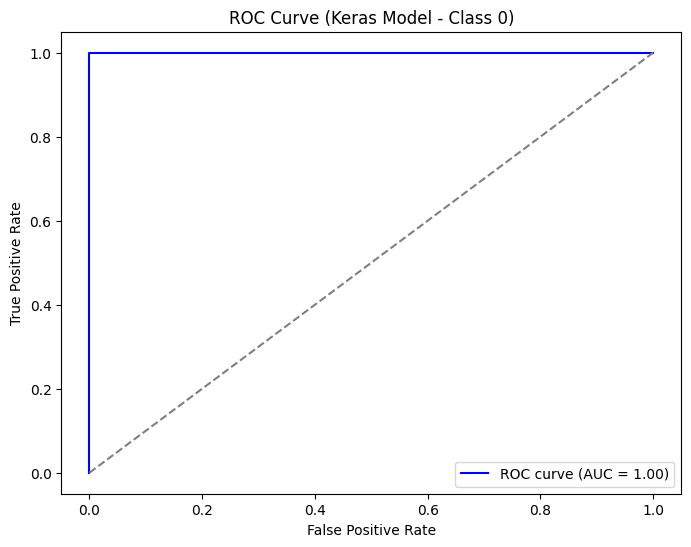

In [ ]:
### WTF   WTF  WTF



from sklearn.preprocessing import label_binarize

# logits = model.predict(X_train).ravel()  # Remove ravel() to keep 2D shape
logits = model.predict(X_train)  # Keep logits as 2D array
print(logits)

# Convert y_train to a binary format for each class
y_train_bin = label_binarize(y_train.values.argmax(axis=1), classes=np.arange(10))

# Calculate ROC curve for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
n_classes = y_train_bin.shape[1]  # Get number of classes

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_train_bin[:, i], logits[:, i])  # Now logits[:, i] is valid
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves for each class (example for class 0)
plt.figure(figsize=(8, 6))
plt.plot(fpr[0], tpr[0], color='blue', label=f'ROC curve (AUC = {roc_auc[0]:.2f})')
plt.plot([0, 1], [0, 1], color='grey', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Keras Model - Class 0)')
plt.legend(loc='lower right')
plt.show()

7


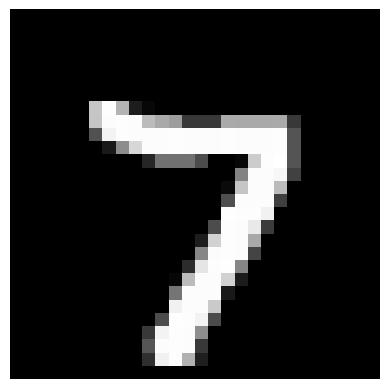

In [ ]:
from random import randint
n = randint(0,33599)
print(results[n])
plt.imshow(X_train[n][:,:,0],cmap="gray")
plt.axis("off")
plt.show()

In [ ]:
df_test = pd.read_csv('/content/drive/MyDrive/digit_test.csv')
df_test

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
27996,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
27997,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
27998,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
df_test = df_test.values.reshape(-1, 28, 28, 1)
df_test = df_test/255

In [ ]:
y_pred = model.predict(df_test)
y_pred = np.argmax(y_pred, axis=1)

875/875 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


In [ ]:
y_pred1 = model1.predict(df_test)
y_pred1 = np.argmax(y_pred1, axis=1)

875/875 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step


In [ ]:
ImageId = range(1,28001)
test_df = pd.DataFrame({'ImageId': ImageId, 'Label':y_pred})

In [ ]:
test_df1 = pd.DataFrame({'ImageId': ImageId, 'Label':y_pred1})
test_df1

,ImageId,Label
0,1,2
1,2,0
2,3,9
3,4,9
4,5,3
...,...,...
27995,27996,9
27996,27997,7
27997,27998,3
27998,27999,9


In [ ]:
test_df1.to_csv('submission_digitRecognizerKaggle_model1.csv', index=False)

In [ ]:
print(test_df)

       ImageId  Label
0            1      2
1            2      0
2            3      9
3            4      0
4            5      3
...        ...    ...
27995    27996      9
27996    27997      7
27997    27998      3
27998    27999      9
27999    28000      2

[28000 rows x 2 columns]


In [ ]:
test_df.to_csv('submission_digitRecognizerKaggle_model.csv', index=False)
test_df.describe()

,ImageId,Label
count,28000.000000,28000.000000
mean,14000.500000,4.447536
std,8083.048105,2.902286
min,1.000000,0.000000
25%,7000.750000,2.000000
50%,14000.500000,4.000000
75%,21000.250000,7.000000
max,28000.000000,9.000000


In [ ]:
# # Set dimensions
# rows, cols = 28, 28

# # Generate a noisy array
# # You can adjust `mean` and `std_dev` for different noise levels
# mean = 0
# std_dev = 10
# noisy_array = np.random.normal(mean, std_dev, (rows, cols))

# # Visualize the noisy array
# plt.imshow(noisy_array, cmap='gray')
# plt.colorbar()
# plt.title("Noisy 28x28 Array")
# plt.show()



In [ ]:
# y = model.predict(noisy_array.reshape(-1,28,28,1))
# y = np.argmax(y, axis=1)
# print(y)

In [ ]:
# import numpy as np

# def create_synthetic_digit(digit):
#     img = np.zeros((28, 28), dtype=np.uint8)
#     if digit == 0:
#         img[8:20, 8] = 255
#         img[8:20, 19] = 255
#         img[8, 8:20] = 255
#         img[19, 8:20] = 255
#     elif digit == 1:
#         img[8:20, 14] = 255
#     elif digit == 2:
#         img[8, 8:20] = 255
#         img[13, 8:20] = 255
#         img[19, 8:20] = 255
#         img[8:14, 19] = 255
#         img[14:20, 8] = 255
#     elif digit == 3:
#         img[8, 8:20] = 255
#         img[13, 10:20] = 255
#         img[19, 8:20] = 255
#         img[8:20, 19] = 255
#     elif digit == 4:
#         img[8:14, 8] = 255
#         img[13, 8:20] = 255
#         img[8:20, 19] = 255
#     elif digit == 5:
#         img[8, 8:20] = 255
#         img[8:14, 8] = 255
#         img[13, 8:20] = 255
#         img[14:20, 19] = 255
#         img[19, 8:20] = 255
#     elif digit == 6:
#         img[8, 10:20] = 255
#         img[8:20, 8] = 255
#         img[13, 8:20] = 255
#         img[14:20, 19] = 255
#         img[19, 8:20] = 255
#     elif digit == 7:
#         img[8, 8:20] = 255
#         img[8:20, 19] = 255
#     elif digit == 8:
#         img[8, 8:20] = 255
#         img[13, 8:20] = 255
#         img[19, 8:20] = 255
#         img[8:20, 8] = 255
#         img[8:20, 19] = 255
#     elif digit == 9:
#         img[8, 8:20] = 255
#         img[8:14, 8] = 255
#         img[8:14, 19] = 255
#         img[13, 8:20] = 255
#         img[14:20, 19] = 255
#     return img

# # Create a dictionary of all digits
# synthetic_digits = {d: create_synthetic_digit(d) for d in range(10)}


In [ ]:
# for digit in synthetic_digits:
#     plt.imshow(synthetic_digits[digit], cmap='gray')
#     plt.title(f"Digit {digit}")
#     plt.show()
#     y = model.predict(synthetic_digits[digit].reshape(-1,28,28,1))
#     print(y)
#     y = np.argmax(y, axis=1)
#     print(y)

In [ ]:
# # This is a 28x28 numpy array representation of the digit "7"
# import numpy as np

# # Create a 28x28 array filled with zeros
# digit_7 = np.zeros((28, 28))

# # Draw the horizontal line at the top
# digit_7[5, 5:23] = 1

# # Draw the diagonal line for the "7"
# for i in range(6, 20):
#     j = int(5 + 0.8 * (i - 5))
#     digit_7[i, j:j+3] = 1

# plt.imshow(digit_7, cmap='gray')
# plt.title(f"Digit {7}")
# plt.show()
# y = model.predict(digit_7.reshape(-1,28,28,1))
# print(y)
# y = np.argmax(y, axis=1)
# print(y)